# 第057单元 语言模型实验与评价
本Notebook按固定协议从零训练三模型，保留所有错误。重跑是复现，不用于试到最好成绩。无网络数据、无付费API。

In [1]:
from pathlib import Path
import json, math, subprocess, sys
import numpy as np
import torch
from IPython.display import display, Image
from experiment import make_data, contamination, wilson, evaluate, run
from model import load_model
root = Path.cwd()
if not (root/'model.py').is_file(): raise RuntimeError('请从057目录运行')
print({'python':sys.version.split()[0],'torch':torch.__version__,'numpy':np.__version__})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'numpy': '2.3.5'}


## 1 先检查拆分
同一规则前缀的四物体变体必须一起移动。完整文本去重不等于题组无泄漏。

In [2]:
docs = make_data()
parts = {split:[r for r in docs if r['split']==split] for split in ['train','validation','test']}
for name,rows in parts.items(): print(name,len(rows),len({r['group'] for r in rows}))
print(contamination(parts['train'],parts['test']))
print('错误注入检查',contamination(parts['train'],parts['test']+[parts['train'][0]]))
for flags in [[],['-O']]: subprocess.run([sys.executable,*flags,'test_experiment.py'],check=True)

train 160 40
validation 48 12
test 48 12
{'exact_document_overlap': 0, 'prefix_group_overlap': 0, 'token_vocabulary_overlap': 17, 'test_documents': 48, 'test_groups': 12}
错误注入检查 {'exact_document_overlap': 1, 'prefix_group_overlap': 1, 'token_vocabulary_overlap': 17, 'test_documents': 49, 'test_groups': 13}


## 2 手算再核验
算出三个目标概率的NLL与PPL。区间用题组n=12，不是文档48或token336。

In [3]:
q=np.array([.5,.25,.125]); losses=-np.log(q)
print('逐项NLL',losses,'平均',losses.mean(),'PPL',np.exp(losses.mean()))
print('正确batch加权',(2*1+1*3)/3)
for k in [0,1,2,6]: print(k,12,wilson(k,12))

逐项NLL [0.69314718 1.38629436 2.07944154] 平均 1.3862943611198906 PPL 4.0
正确batch加权 1.6666666666666667
0 12 [0.0, 0.2425007574992425]
1 12 [0.014864709450773478, 0.35388592179859524]
2 12 [0.04696414761482223, 0.44803635738467273]
6 12 [0.2537781703934222, 0.7462218296065778]


## 3 固定协议重跑
三个初始化种子、相同批次序列、相同步数，不择优。输出写入notebook_replay。

In [4]:
result=run(root/'notebook_replay')
for rr in result['runs']:
    t=rr['test']
    print(rr['seed'],{k:t[k] for k in ['nll','perplexity','effective_tokens','format_rate','task_success_count','independent_prompt_groups','single_reference_exact_match','wilson95_task_success']})
print('基线',result['baselines'])

5701 {'nll': 1.1396516561508179, 'perplexity': 3.1256792545318604, 'effective_tokens': 336, 'format_rate': 1.0, 'task_success_count': 1, 'independent_prompt_groups': 12, 'single_reference_exact_match': 0.020833333333333332, 'wilson95_task_success': [0.014864709450773478, 0.35388592179859524]}
5702 {'nll': 1.1539568901062012, 'perplexity': 3.1707143783569336, 'effective_tokens': 336, 'format_rate': 1.0, 'task_success_count': 1, 'independent_prompt_groups': 12, 'single_reference_exact_match': 0.020833333333333332, 'wilson95_task_success': [0.014864709450773478, 0.35388592179859524]}
5703 {'nll': 1.1208398342132568, 'perplexity': 3.067429304122925, 'effective_tokens': 336, 'format_rate': 1.0, 'task_success_count': 2, 'independent_prompt_groups': 12, 'single_reference_exact_match': 0.041666666666666664, 'wilson95_task_success': [0.04696414761482223, 0.44803635738467273]}
基线 {'uniform_nll': 2.995732273553991, 'train_bigram_add1_test_nll': 1.4858757606583723}


## 4 从原始记录重算汇总
NLL分母336；规则分母12。回读实际权重核对保存结果。

In [5]:
for rr in result['runs']:
    t=rr['test']; total=sum(r['sum_nll'] for r in t['document_nll'])
    print(rr['seed'],'由文档重算NLL',total/336,'错误分类',t['error_counts'])
    model=load_model(root/'notebook_replay'/f"weights_s{rr['seed']}.npz")
    restored=evaluate(model,parts['test'],True)
    if abs(restored['nll']-t['nll'])>1e-6: raise AssertionError('权重回读不一致')
    if sum(t['error_counts'].values()) != 12: raise AssertionError('错误分类不完整')
first=result['runs'][0]['test']['predictions'][0]
print('首个完整记录',first)

5701 由文档重算NLL 1.1396516944680894 错误分类 {'success': 1, 'wrong_rule': 11, 'format_or_stop_failure': 0}
5702 由文档重算NLL 1.1539569866089594 错误分类 {'success': 1, 'wrong_rule': 11, 'format_or_stop_failure': 0}
5703 由文档重算NLL 1.1208397008123852 错误分类 {'success': 2, 'wrong_rule': 10, 'format_or_stop_failure': 0}
首个完整记录 {'group': 42, 'prompt': [1, 5, 9, 13], 'gold_color': 5, 'prediction': [4, 16, 19, 2], 'rule_correct': False, 'format_correct': True, 'task_success': False, 'exact_match_count': 0, 'references': 4, 'error': 'wrong_rule'}


## 5 与随包记录对照并重画图
保持负面结果；测试失败不应通过更换种子掩盖。时间不是严格复现目标。

5701 NLL差 0.0 输出相同 True
5702 NLL差 0.0 输出相同 True
5703 NLL差 0.0 输出相同 True


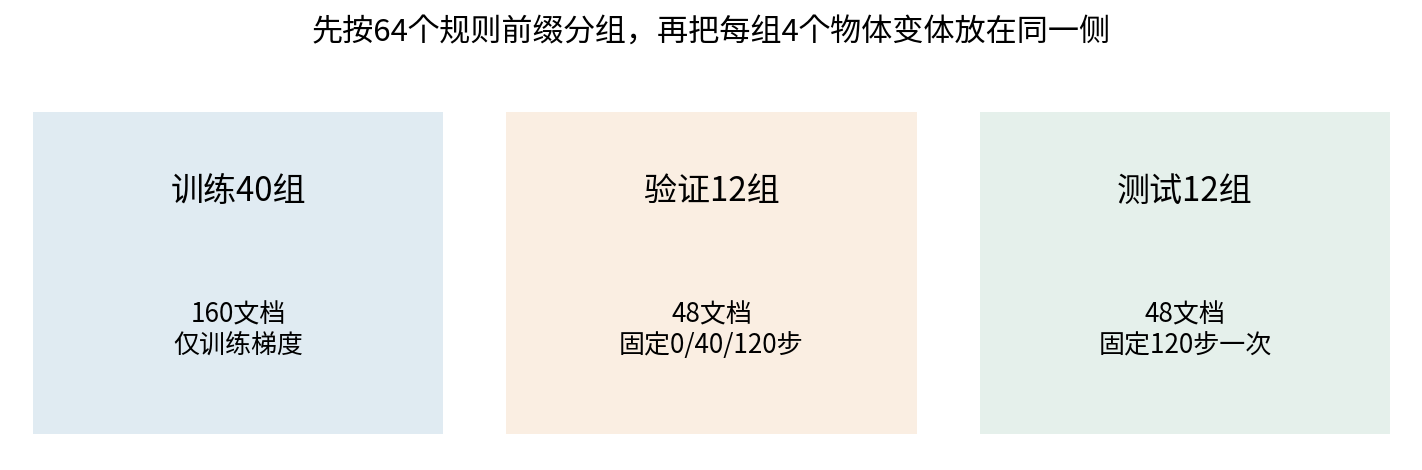

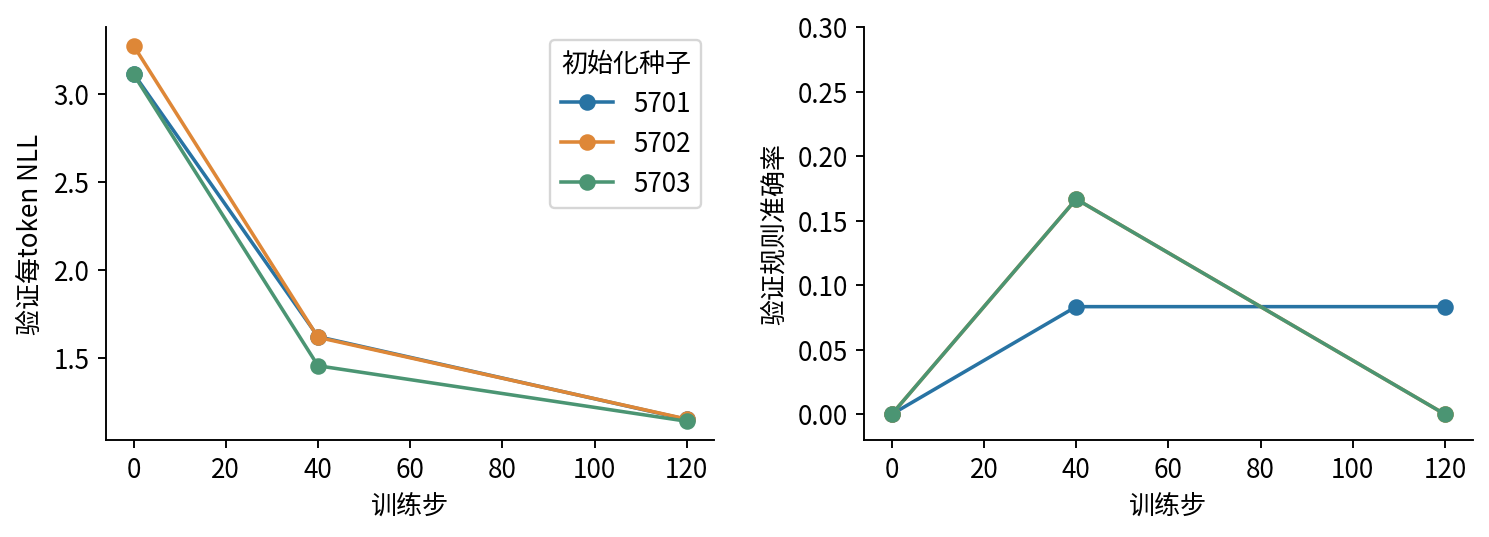

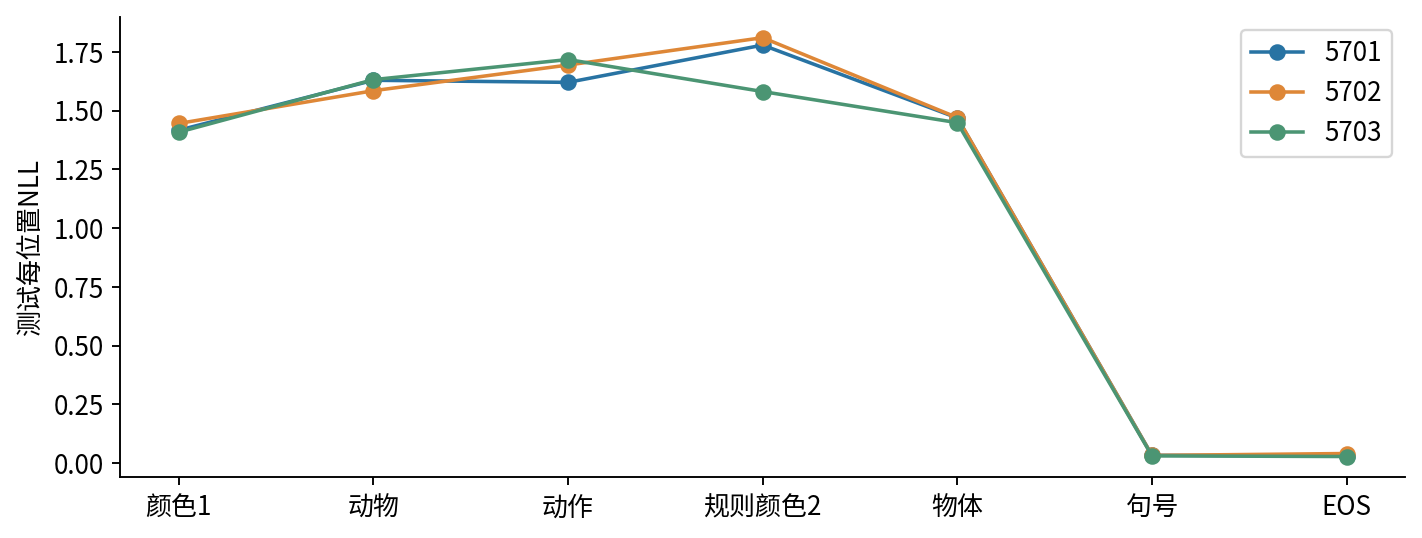

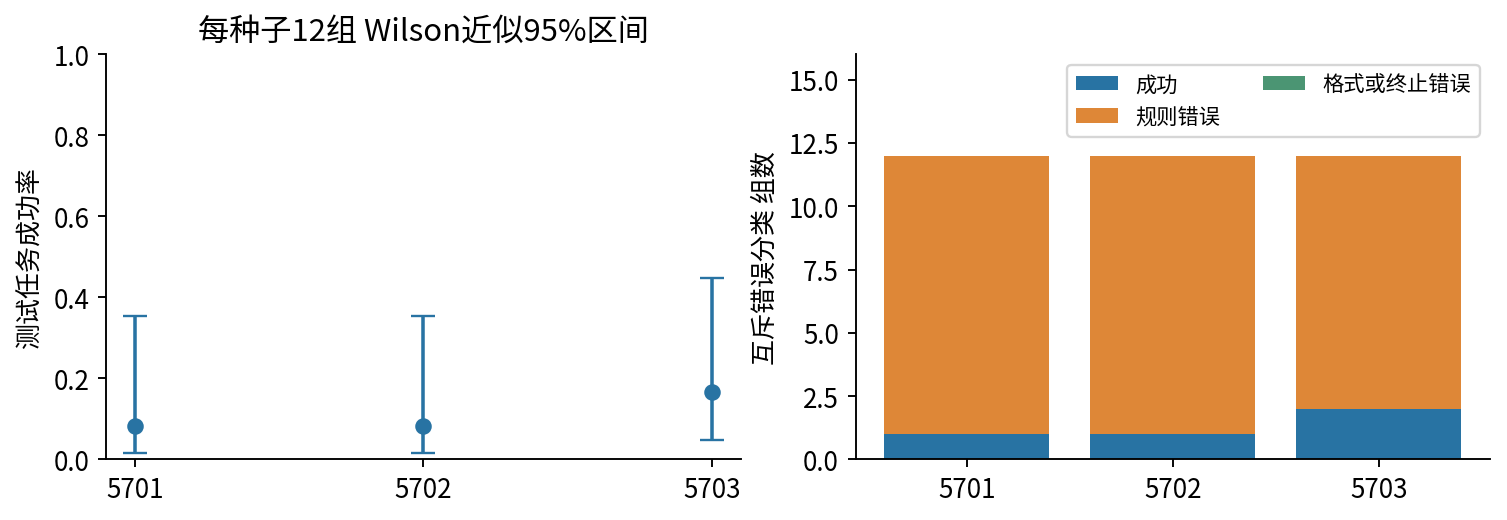

In [6]:
recorded=json.loads((root/'outputs/results.json').read_text())
for a,b in zip(result['runs'],recorded['runs']):
    print(a['seed'],'NLL差',a['test']['nll']-b['test']['nll'],'输出相同',a['test']['predictions']==b['test']['predictions'])
subprocess.run([sys.executable,'make_figures.py','--results','notebook_replay/results.json','--output','notebook_replay/figures'],check=True)
for name in ['01_group_split.png','02_metric_gap.png','03_position_loss.png','04_uncertainty_errors.png']:
    display(Image(filename=str(root/'notebook_replay/figures'/name)))

## 6 练习与结论
解释group42为什么格式正确仍失败。证明本课单参考EM上限25%。说明三个种子不能当36道独立新题。列出两项本实验没有提供的语言能力证据。人工表保持空白，除非确有真实评价者；不得把自动分数伪装成人工分。详解见answers.pdf。